# Data Mining 1 – CA2  
### Predictive Modelling with World Bank & UN HDI Data  

**Student:** Berkay Eren <br>
**Module:** Data Mining 1 <br>
**Lecturer:** Dr Bernard Butler  

---

## Introduction

In this notebook, I use international development data from the **World Bank** and the **UN Human Development Report** to:

1. Predict **life expectancy at birth** using economic and social indicators (regression).
2. Predict a country’s **Human Development Index (HDI) group** using those indicators (classification).
3. Discover **natural groupings of countries** and compare them with the official HDI groups (clustering).

My aim is to go through the full data mining process:

- Explore and understand the data (EDA),
- Prepare a clean modelling dataset,
- Build and evaluate supervised models (regression & classification),
- Apply unsupervised learning (clustering),
- Interpret the results.

Throughout the notebook, I will try to explain my decisions and trade-offs, especially around data preparation and model choice. I hope the notebook will be readable as a **report** even if the reader is not focused on the code.

## Setup and Data Loading

I start by importing the main libraries for:

- **pandas / numpy** for data handling,
- **matplotlib / seaborn** for plots,
- **scikit-learn** for modelling and evaluation.

Next, I load the four files provided for the assignment:

- `worldBank_Data.csv` – economic & social indicators by country and year.
- `HDI_by_country.csv` – HDI score and HDI class by country.
- `HDR25_Statistical_Annex_HDI_Table.xlsx` – additional UN HDI details.
- `worldBank_SeriesMetadata.xlsx` – metadata describing each World Bank indicator.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

sns.set(style="whitegrid")

# Load datasets
wb = pd.read_csv("data/worldBank_Data.csv")
hdi = pd.read_csv("data/HDI_by_country.csv")
hdi_table = pd.read_excel("data/HDR25_Statistical_Annex_HDI_Table.xlsx")
meta = pd.read_excel("data/worldBank_SeriesMetadata.xlsx")

## EDA Pass 1: First Look at the Data

In this first pass I want to understand the structure of the four files provided for the assignment.  
I do not clean anything yet. My aim is to see what each file contains, how the information is organised, and what role each file will play later.

The two main files for modelling are:

• `worldBank_Data.csv`, which holds all the economic and social indicators by country and year  
• `HDI_by_country.csv`, which holds the HDI score and the HDI class for each country

The other two files help with interpretation:

• `HDR25_Statistical_Annex_HDI_Table.xlsx`, which gives extra information about HDI and its components  
• `worldBank_SeriesMetadata.xlsx`, which explains what each World Bank indicator measures

In this step I check the structure of each file so I know what the rows represent, how the columns are arranged, and what kind of preparation work will be needed in the next pass.


In [18]:
wb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16763 entries, 0 to 16762
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   16760 non-null  object
 1   Country Code   16758 non-null  object
 2   Series Name    16758 non-null  object
 3   Series Code    16758 non-null  object
 4   2011 [YR2011]  16758 non-null  object
 5   2012 [YR2012]  16758 non-null  object
 6   2013 [YR2013]  16758 non-null  object
 7   2014 [YR2014]  16758 non-null  object
 8   2015 [YR2015]  16758 non-null  object
 9   2016 [YR2016]  16758 non-null  object
 10  2017 [YR2017]  16758 non-null  object
 11  2018 [YR2018]  16758 non-null  object
 12  2019 [YR2019]  16758 non-null  object
 13  2020 [YR2020]  16758 non-null  object
 14  2021 [YR2021]  16758 non-null  object
 15  2022 [YR2022]  16758 non-null  object
 16  2023 [YR2023]  16758 non-null  object
 17  2024 [YR2024]  16758 non-null  object
dtypes: object(18)
memory usage

In [19]:
wb.head()

,Country Name,Country Code,Series Name,Series Code,2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Albania,ALB,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,69.1,71.3,73.1,75.2,76.6,78.3,79.6,80.7,82,83.1,83.6,84.6,..,..
1,Albania,ALB,Access to electricity (% of population),EG.ELC.ACCS.ZS,99.7,99.9,99.9,100,100,99.9,99.9,100,100,100,100,100,100,..
2,Albania,ALB,Account ownership at a financial institution o...,FX.OWN.TOTL.FE.ZS,22.6726112235836,..,..,33.5942341082043,..,..,38.1029578691588,..,..,..,45.6861097525436,..,..,41.1560488283684
3,Albania,ALB,Account ownership at a financial institution o...,FX.OWN.TOTL.MA.ZS,33.6646774405553,..,..,42.5196913972188,..,..,42.0435031953365,..,..,..,42.5851653897092,..,..,51.4508986584924
4,Albania,ALB,Adequacy of social protection and labor progra...,per_allsp.adq_pop_tot,..,27.9899243993596,..,..,..,..,..,..,..,..,..,..,..,..


In [20]:
hdi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    193 non-null    object 
 1   HDI score  193 non-null    float64
 2   HDI Class  193 non-null    object 
dtypes: float64(1), object(2)
memory usage: 4.7+ KB


In [21]:
hdi.head()

,Country,HDI score,HDI Class
0,Iceland,0.972,Very High HDI
1,Norway,0.970,Very High HDI
2,Switzerland,0.970,Very High HDI
3,Denmark,0.962,Very High HDI
4,Germany,0.959,Very High HDI


In [22]:
hdi_table.head()

,Unnamed: 0,Table 1. Human Development Index and its components,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,SDG3,NaN,SDG4.3,NaN,SDG4.4,NaN,SDG8.5,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Human Development Index (HDI),NaN,Life expectancy at birth,NaN,Expected years of schooling,NaN,Mean years of schooling,NaN,Gross national income (GNI) per capita,NaN,GNI per capita rank minus HDI rank,NaN,HDI rank
4,HDI rank,Country,Value,NaN,(years),NaN,(years),NaN,(years),NaN,(2021 PPP $),NaN,NaN,NaN,NaN


In [23]:
meta.head()

,Code,License Type,Indicator Name,Short definition,Long definition,Source,Topic,Dataset,Unit of measure,Periodicity,...,Development relevance,Limitations and exceptions,Other notes,License URL,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,EG.CFT.ACCS.ZS,CC BY-4.0,Access to clean fuels and technologies for coo...,Access to clean fuels and technologies for coo...,Access to clean fuels and technologies for coo...,"Tracking SDG 7: The Energy Progress Report, In...",Environment: Energy production & use,WDI,% (share) of population,Annual,...,NaN,NaN,NaN,https://datacatalog.worldbank.org/public-licen...,NaN,NaN,NaN,NaN,NaN,NaN
1,EG.ELC.ACCS.ZS,CC BY-4.0,Access to electricity (% of population),Access to electricity is the percentage of pop...,Access to electricity is the percentage of pop...,"SDG 7.1.1 Electrification Dataset, World Bank ...",Environment: Energy production & use,WDI,% (share) of population,Annual,...,Maintaining reliable and secure electricity se...,NaN,NaN,https://datacatalog.worldbank.org/public-licen...,NaN,NaN,NaN,NaN,NaN,NaN
2,FX.OWN.TOTL.FE.ZS,CC BY-4.0,Account ownership at a financial institution o...,Account denotes the percentage of respondents ...,Account denotes the percentage of respondents ...,"Global Findex Database, World Bank (WB), uri: ...",Financial Sector: Access,WDI,NaN,Triennial,...,Financial inclusion allows individuals and fir...,NaN,Each economy is classified based on the classi...,https://datacatalog.worldbank.org/public-licen...,NaN,NaN,NaN,NaN,NaN,NaN
3,FX.OWN.TOTL.MA.ZS,CC BY-4.0,Account ownership at a financial institution o...,Account denotes the percentage of respondents ...,Account denotes the percentage of respondents ...,"Global Findex Database, World Bank (WB), uri: ...",Financial Sector: Access,WDI,Weighted average,Triennial,...,financial inclusion is a key pillar to green f...,NaN,Each economy is classified based on the classi...,https://datacatalog.worldbank.org/public-licen...,NaN,NaN,NaN,NaN,NaN,NaN
4,per_allsp.adq_pop_tot,CC BY-4.0,Adequacy of social protection and labor progra...,Adequacy of social protection and labor progra...,Adequacy of social protection and labor progra...,ASPIRE: The Atlas of Social Protection - Indic...,Social Protection & Labor: Performance,WDI,% of Total,Annual,...,"By harmonizing survey data for 129 countries, ...",When interpreting ASPIRE performance indicator...,NaN,https://datacatalog.worldbank.org/public-licen...,NaN,NaN,NaN,NaN,NaN,NaN


### Findings from EDA Pass 1

After checking all four files, I learned the following:

• The World Bank dataset is very large and stored in a long format. Each row represents one indicator for one country, and the year values run from 2011 to 2024.  
  All year columns are stored as text, and missing values appear as “..”. The year column names also include labels such as “[YR2011]”, so this file will need cleaning and reshaping before modelling.

• The HDI dataset is clean and simple. It has one row per country, with no missing values. This file is ready to merge once the World Bank data is prepared.

• The HDI statistical annex is not in a tidy format. It is mainly descriptive and is better used as background information rather than modelling data.

• The World Bank metadata describes the indicators in detail. It will be useful later when interpreting model results but is not needed during data preparation.

Overall, Pass 1 shows that the main preparation work will focus on cleaning and restructuring the World Bank dataset. Once that is done, I can merge it with the HDI data and start building models.

## EDA Pass 2: Cleaning and Preparing the Dataset

In this pass I prepare the World Bank dataset so I can analyse missingness and reshape it in the next steps.  
Since the file comes directly from the World Bank, it contains a few issues that must be fixed before I can work with it.

In this step I do the following:

• Convert the “..” entries into proper missing values (NaN).  
• Clean the year column names by removing the “[YRxxxx]” labels.  
• Convert all year columns to numeric values.  
• Remove duplicated rows, if any exist.  
• Check for missing country names or indicator codes.  
• Standardise text fields by stripping any trailing spaces.  
• Confirm that non-year columns look correct and consistent.

These tasks prepare the dataset for Pass 3, where I will analyse missingness and select a modelling year.

In [24]:
# working copy
wb_clean = wb.copy()

# replace ".." with NaN
wb_clean = wb_clean.replace("..", np.nan)

# strip extra spaces from text columns
text_cols = ["Country Name", "Country Code", "Series Name", "Series Code"]
for col in text_cols:
    wb_clean[col] = wb_clean[col].astype(str).str.strip()

# remove rows with missing country or missing indicator code
wb_clean = wb_clean.dropna(subset=["Country Name", "Series Code"])

# remove duplicate rows if they exist
wb_clean = wb_clean.drop_duplicates()

# clean year column names by removing "[YRxxxx]" labels
wb_clean.columns = wb_clean.columns.str.replace(r"\s+\[YR\d+\]", "", regex=True)

# identify year columns
year_cols = [col for col in wb_clean.columns if col.isdigit()]

# convert year columns to numeric safely
for col in year_cols:
    wb_clean[col] = pd.to_numeric(wb_clean[col], errors="coerce")

# preview after cleaning
wb_clean.head()


,Country Name,Country Code,Series Name,Series Code,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Albania,ALB,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,69.100000,71.300000,73.1,75.200000,76.6,78.3,79.600000,80.7,82.0,83.1,83.600000,84.6,NaN,NaN
1,Albania,ALB,Access to electricity (% of population),EG.ELC.ACCS.ZS,99.700000,99.900000,99.9,100.000000,100.0,99.9,99.900000,100.0,100.0,100.0,100.000000,100.0,100.0,NaN
2,Albania,ALB,Account ownership at a financial institution o...,FX.OWN.TOTL.FE.ZS,22.672611,NaN,NaN,33.594234,NaN,NaN,38.102958,NaN,NaN,NaN,45.686110,NaN,NaN,41.156049
3,Albania,ALB,Account ownership at a financial institution o...,FX.OWN.TOTL.MA.ZS,33.664677,NaN,NaN,42.519691,NaN,NaN,42.043503,NaN,NaN,NaN,42.585165,NaN,NaN,51.450899
4,Albania,ALB,Adequacy of social protection and labor progra...,per_allsp.adq_pop_tot,NaN,27.989924,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# to verify if everything is correct
wb_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16761 entries, 0 to 16762
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  16761 non-null  object 
 1   Country Code  16761 non-null  object 
 2   Series Name   16761 non-null  object 
 3   Series Code   16761 non-null  object 
 4   2011          8692 non-null   float64
 5   2012          8467 non-null   float64
 6   2013          8396 non-null   float64
 7   2014          8941 non-null   float64
 8   2015          9369 non-null   float64
 9   2016          8606 non-null   float64
 10  2017          9017 non-null   float64
 11  2018          8625 non-null   float64
 12  2019          9326 non-null   float64
 13  2020          8221 non-null   float64
 14  2021          8243 non-null   float64
 15  2022          6924 non-null   float64
 16  2023          5627 non-null   float64
 17  2024          2635 non-null   float64
dtypes: float64(14), object(4)
memor

### Findings from EDA Pass 2

After completing this cleaning step, the dataset is in a much better shape for analysis.

• All “..” entries were converted into NaN, so pandas now recognises them as missing values.  
• The year columns were cleaned and now contain only the year number, which makes them easier to work with.  
• The year values were converted to numeric without errors, which confirms that the entries are now consistent.  
• Duplicate rows were removed, and I checked for missing country names or indicator codes.  
• Text columns were standardised by removing extra spaces.

At this point, the dataset is still in long format, but it is clean enough to analyse missingness by year and by indicator. The main issues (non-numeric year values and unrecognised missing values) have been resolved, so I can now move on to Pass 3 where I decide which year to use for modelling.


## EDA Pass 3: Missingness and Selecting Columns

In this pass I want to understand how complete the World Bank data is.  
Since the indicators are reported for many years, I start by checking how much data is missing in each year.  
This helps me see which years are usable and which ones are too incomplete.

After looking at the missingness by year, I choose one year to use for all modelling tasks.  
Then I check missingness again, this time for each indicator inside the chosen year.  
The goal is to keep indicators that have enough data and remove the ones that are mostly empty.

By the end of this pass I want to know which year I will use, which indicators have enough values and which parts of the dataset are ready for the next steps.

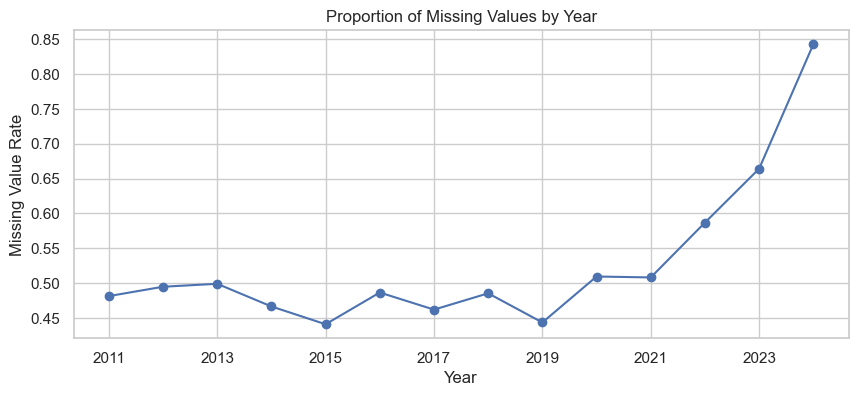

In [27]:
missing_by_year = wb_clean[year_cols].isna().mean().sort_index()
plt.figure(figsize=(10,4))
missing_by_year.plot(marker="o")
plt.title("Proportion of Missing Values by Year")
plt.xlabel("Year")
plt.ylabel("Missing Value Rate")
plt.show()

### Choosing the Modelling Year

When I looked at the missingness by year, I saw that the earlier years had more complete data,  
while the newer years were much less complete.  
The biggest drop in reporting happens after 2021.

2019 has good coverage and is recent enough to be useful for the assignment.  
It is a clear choice because it avoids the missing values of the later years  
and still gives a modern snapshot of each country.

For this reason I will use **2019** as the modelling year.

In [30]:
chosen_year = "2019"

indicator_missing = (
    wb_clean[["Series Code", "Series Name", chosen_year]]
    .groupby(["Series Code", "Series Name"])[chosen_year]
    .apply(lambda x: x.isna().mean())
    .sort_values()
)

indicator_missing.head(20), indicator_missing.tail(20)

(Series Code           Series Name                                                                                          
 SP.POP.DPND           Age dependency ratio (% of working-age population)                                                       0.003759
 SP.ADO.TFRT           Adolescent fertility rate (births per 1,000 women ages 15-19)                                            0.003759
 SP.DYN.LE00.FE.IN     Life expectancy at birth, female (years)                                                                 0.003759
 SP.DYN.LE00.MA.IN     Life expectancy at birth, male (years)                                                                   0.003759
 SP.POP.TOTL.MA.IN     Population, male                                                                                         0.003759
 SP.POP.TOTL.FE.IN     Population, female                                                                                       0.003759
 SP.DYN.CBRT.IN        Birth rate, crude (per 1,000 p

In [31]:
# selecting usable indicators
max_missing = 0.40
good_indicators = indicator_missing[indicator_missing <= max_missing]
len(good_indicators)

30

In [32]:
wb_2019 = wb_clean[["Country Name", "Country Code", "Series Code", "Series Name", chosen_year]]

wb_2019 = wb_2019.merge(
    good_indicators.reset_index()[["Series Code"]],
    on="Series Code",
    how="inner"
)

wb_2019.head()

,Country Name,Country Code,Series Code,Series Name,2019
0,Albania,ALB,EG.CFT.ACCS.ZS,Access to clean fuels and technologies for coo...,8.200000e+01
1,Albania,ALB,EG.ELC.ACCS.ZS,Access to electricity (% of population),1.000000e+02
2,Albania,ALB,NY.ADJ.NNTY.KD.ZG,Adjusted net national income (annual % growth),8.407967e-01
3,Albania,ALB,NY.ADJ.NNTY.KD,Adjusted net national income (constant 2015 US$),1.052568e+10
4,Albania,ALB,NY.ADJ.NNTY.PC.KD,Adjusted net national income per capita (const...,3.687799e+03


### Findings from EDA Pass 3

The missingness analysis helped narrow the dataset to a usable snapshot. 2019 provides the best balance between recency and completeness, which makes it a suitable base year for all modelling tasks.

The indicator-level missingness showed that some indicators are widely reported, while others have very limited data for 2019. By keeping indicators with at least 60 percent availability, I obtained a more reliable set of features for modelling.

At the end of Pass 3 I now have: <br>
• a clear modelling year (2019),  
• a filtered list of indicators with enough data,  
• and a cleaner dataset that is ready to be reshaped into one row per country.

This completes the exploratory work needed before building the modelling dataset.